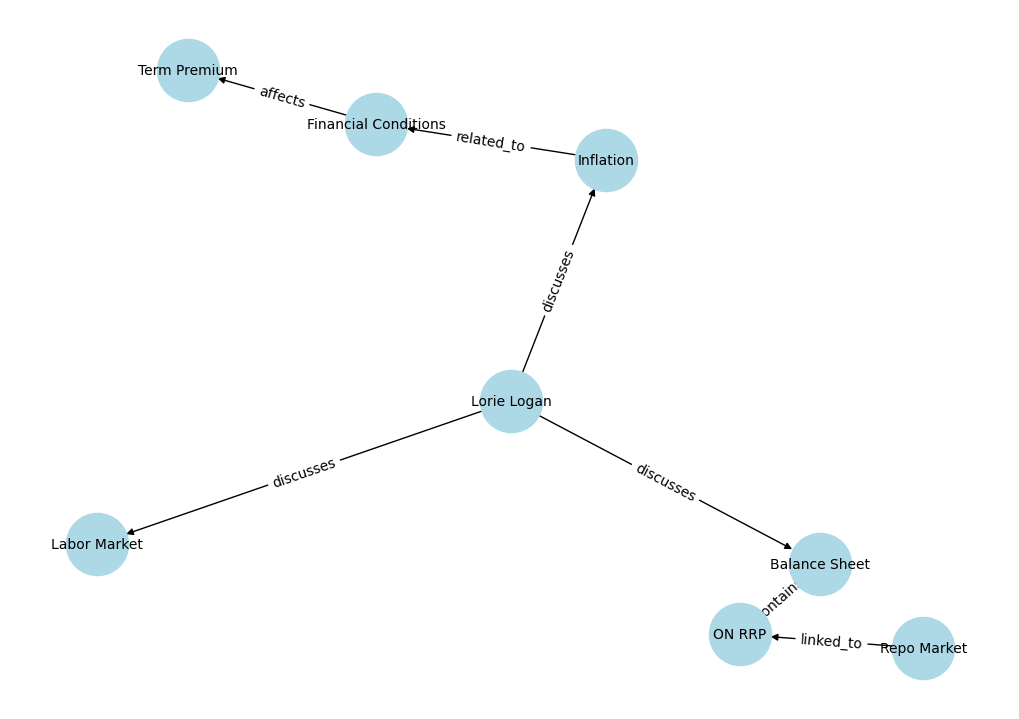

In [1]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.DiGraph()

# Nodes
nodes = [
    "Lorie Logan", "Inflation", "Labor Market", "Balance Sheet",
    "Financial Conditions", "Term Premium", "Repo Market", "ON RRP"
]
G.add_nodes_from(nodes)

# Edges
edges = [
    ("Lorie Logan", "Inflation", "discusses"),
    ("Lorie Logan", "Labor Market", "discusses"),
    ("Lorie Logan", "Balance Sheet", "discusses"),
    ("Inflation", "Financial Conditions", "related_to"),
    ("Financial Conditions", "Term Premium", "affects"),
    ("Balance Sheet", "ON RRP", "contains"),
    ("Repo Market", "ON RRP", "linked_to"),
]
G.add_edges_from([(a, b, {"relation": r}) for a, b, r in edges])

# Visualize
pos = nx.spring_layout(G, seed=42)
plt.figure(figsize=(10, 7))
nx.draw(G, pos, with_labels=True, node_color="lightblue", node_size=2000, font_size=10, arrows=True)
edge_labels = nx.get_edge_attributes(G, "relation")
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)
plt.show()


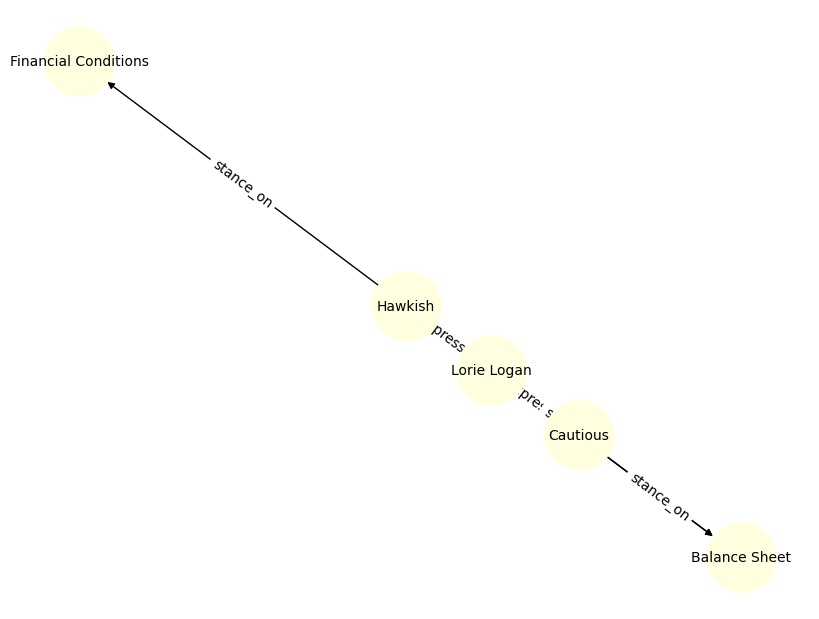

In [2]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.DiGraph()

nodes = [
    "Lorie Logan", "Hawkish", "Cautious",
    "Balance Sheet", "Financial Conditions"
]
G.add_nodes_from(nodes)

edges = [
    ("Lorie Logan", "Hawkish", "expresses"),
    ("Lorie Logan", "Cautious", "expresses"),
    ("Hawkish", "Financial Conditions", "stance_on"),
    ("Hawkish", "Balance Sheet", "stance_on"),
    ("Cautious", "Hawkish", "qualifies"),
    ("Cautious", "Balance Sheet", "stance_on"),
]
G.add_edges_from([(a, b, {"relation": r}) for a, b, r in edges])

pos = nx.spring_layout(G, seed=7)
plt.figure(figsize=(8,6))
nx.draw(G, pos, with_labels=True, node_color="lightyellow", node_size=2500, font_size=10, arrows=True)
edge_labels = nx.get_edge_attributes(G, "relation")
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)
plt.show()


C:\Users\MainUser\AppData\Local\Temp\ipykernel_15776\2583909683.py:74: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


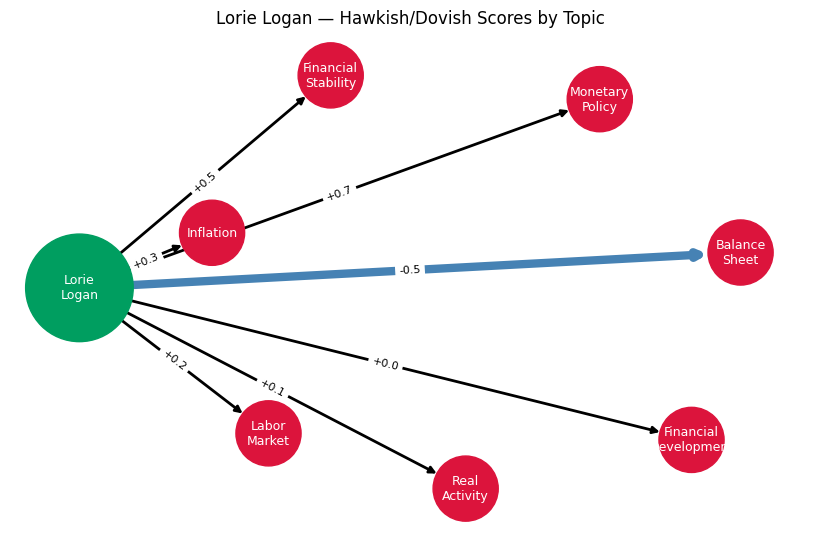

In [58]:
import matplotlib.pyplot as plt
import networkx as nx

# Hawkish/Dovish scores (-1 = dovish, +1 = hawkish)
scores = {
    "Balance Sheet": -0.5,
    "Labor Market": 0.2,
    "Inflation": 0.3,
    "Monetary Policy": 0.7,
    "Financial Stability": 0.5,
    "Financial Development": 0.0,
    "Real Activity": +0.1
}

G = nx.DiGraph()

# Nodes
G.add_nodes_from(["Lorie Logan"] + list(scores.keys()))

# Edges with weights
for topic in scores:
    G.add_edge("Lorie Logan", topic, weight=2, color='black')

# Manually make Balance Sheet red for emphasis
G["Lorie Logan"]["Balance Sheet"]["color"] = "#4682B4"
G["Lorie Logan"]["Balance Sheet"]["weight"] = 6

# Extract edge attributes
edges = G.edges(data=True)
colors = [e[2]['color'] for e in edges]
widths = [e[2]['weight'] for e in edges]

# Layout
pos = nx.spring_layout(G, seed=42)
pos["Lorie Logan"] = (-1.5, 0)  # move main node left

node_sizes = []
for n in G.nodes():
    label_len = len(n)
    if n == "Lorie Logan":
        node_sizes.append(6000)
    else:
        node_sizes.append(1000 + label_len * 150)  # adjust multiplier as needed
labels = {n: n.replace(" ", "\n") for n in G.nodes()}
# Draw network
plt.figure(figsize=(8, 5))
# Draw only nodes and edges (no labels)
nx.draw(
    G, pos,
    with_labels=False,   # turn off built-in labels
    node_color=['#009E60'] + ['#DC143C'] * len(scores),
    edge_color=colors, width=widths,
    node_size=[6000] + [2200] * len(scores),
    arrows=True
)

# Then overlay custom labels (supports wrapping, custom color, etc.)
nx.draw_networkx_labels(
    G, pos,
    labels=labels,       # your dictionary, e.g. {'Financial Development': 'Financial\nDevelopment'}
    font_size=9,
    font_color='white'
)

# === Add annotations (scores) ===
edge_labels = {(u, v): f"{scores[v]:+.1f}" for u, v in G.edges()}
nx.draw_networkx_edge_labels(
    G, pos, edge_labels=edge_labels,

    font_color='black', font_size=8, label_pos=0.5
)

plt.title("Lorie Logan — Hawkish/Dovish Scores by Topic", fontsize=12)
plt.tight_layout()
plt.savefig("logan_network_annotated.png", dpi=300, bbox_inches='tight')
plt.show()


C:\Users\MainUser\AppData\Local\Temp\ipykernel_15776\2899364315.py:75: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


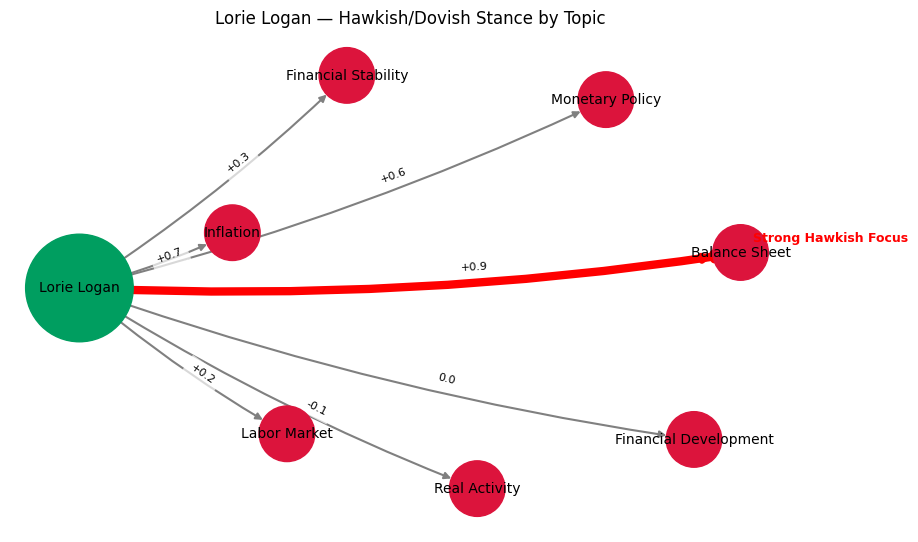

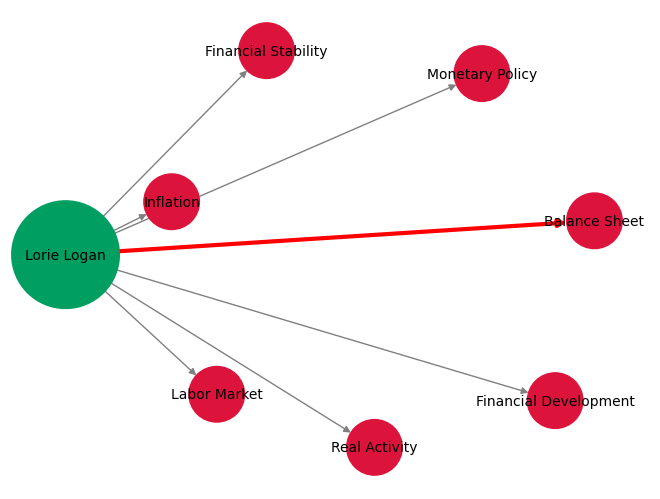

In [39]:
import networkx as nx
#%matplotlib inline
import matplotlib
matplotlib.use("module://matplotlib_inline.backend_inline")


import matplotlib.pyplot as plt

G = nx.DiGraph()

# Nodes
G.add_nodes_from(["Lorie Logan", "Balance Sheet", "Labor Market", "Inflation",
                  "Monetary Policy","Financial Stability", "Financial Development",
                  "Real Activity"])
# Hawkish/Dovish scores (-1 = dovish, +1 = hawkish)
scores = {
    "Balance Sheet": 0.9,
    "Labor Market": 0.2,
    "Inflation": 0.7,
    "Monetary Policy": 0.6,
    "Financial Stability": 0.3,
    "Financial Development": 0.0,
    "Real Activity": -0.1
}

# Edges with weights
G.add_edge("Lorie Logan", "Balance Sheet", weight=3, color='red')
G.add_edge("Lorie Logan", "Labor Market", weight=1, color='gray')
G.add_edge("Lorie Logan", "Inflation", weight=1, color='gray')
G.add_edge("Lorie Logan", "Monetary Policy", weight=1, color='gray')
G.add_edge("Lorie Logan", "Financial Stability", weight=1, color='gray')
G.add_edge("Lorie Logan", "Financial Development", weight=1, color='gray')
G.add_edge("Lorie Logan", "Real Activity", weight=1, color='gray')

# Extract attributes
edges = G.edges(data=True)
colors = [e[2]['color'] for e in edges]
widths = [e[2]['weight'] for e in edges]

pos = nx.spring_layout(G, seed=42)  # reproducible layout
pos["Lorie Logan"] = (-1.5, 0)  # move main node left

nx.draw(G, pos, with_labels=True, node_color=['#009E60','#DC143C','#DC143C','#DC143C',
                                              '#DC143C','#DC143C','#DC143C', '#DC143C'],
        edge_color=colors, width=widths, node_size=[6000,1600,1600,1600, 1600,1600,1600, 1600],
        arrows=True, font_size=10)
#plt.show()
plt.savefig("logan_network.png", dpi=300, bbox_inches='tight')


C:\Users\MainUser\AppData\Local\Temp\ipykernel_15776\4027366043.py:33: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("RdBu_r")  # blue = dovish, red = hawkish


ValueError: Unable to determine Axes to steal space for Colorbar. Either provide the *cax* argument to use as the Axes for the Colorbar, provide the *ax* argument to steal space from it, or add *mappable* to an Axes.

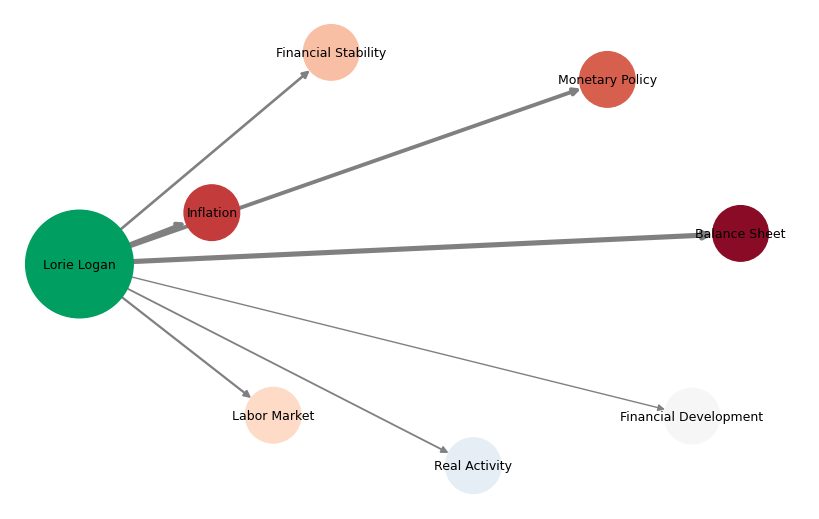

In [38]:
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import Normalize

# Create graph
G = nx.DiGraph()

topics = [
    "Balance Sheet", "Labor Market", "Inflation",
    "Monetary Policy", "Financial Stability",
    "Financial Development", "Real Activity"
]
G.add_nodes_from(["Lorie Logan"] + topics)

# Hawkish/Dovish scores (-1 = dovish, +1 = hawkish)
scores = {
    "Balance Sheet": 0.9,
    "Labor Market": 0.2,
    "Inflation": 0.7,
    "Monetary Policy": 0.6,
    "Financial Stability": 0.3,
    "Financial Development": 0.0,
    "Real Activity": -0.1
}

# Edges with weights based on |score|
for topic in topics:
    G.add_edge("Lorie Logan", topic, weight=abs(scores[topic]) * 3 + 1)

# === Color scaling ===
norm = Normalize(vmin=-1, vmax=1)
cmap = cm.get_cmap("RdBu_r")  # blue = dovish, red = hawkish

node_colors = []
for node in G.nodes():
    if node == "Lorie Logan":
        node_colors.append("#009E60")  # green for speaker
    else:
        node_colors.append(cmap(norm(scores[node])))

# === Layout ===
pos = nx.spring_layout(G, seed=42)
pos["Lorie Logan"] = (-1.5, 0)  # fix Logan to left

# Extract edge attributes
edges = G.edges(data=True)
edge_widths = [e[2]['weight'] for e in edges]

# === Draw graph ===
plt.figure(figsize=(8, 5))
nx.draw(
    G, pos,
    with_labels=True,
    node_color=node_colors,
    edge_color='gray',
    width=edge_widths,
    node_size=[6000 if n == "Lorie Logan" else 1600 for n in G.nodes()],
    arrows=True,
    font_size=9,
)

# === Colorbar legend ===
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm)
cbar.set_label("Dovish (-1)  ←→  Hawkish (+1)", rotation=270, labelpad=15)

plt.title("Lorie Logan — Hawkish/Dovish Stance by Topic", fontsize=12)
plt.savefig("logan_network_scaled.png", dpi=300, bbox_inches='tight')
plt.show()


C:\Users\MainUser\AppData\Local\Temp\ipykernel_15776\3709108068.py:23: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("RdBu_r")  # reversed so red = hawkish


ValueError: Unable to determine Axes to steal space for Colorbar. Either provide the *cax* argument to use as the Axes for the Colorbar, provide the *ax* argument to steal space from it, or add *mappable* to an Axes.

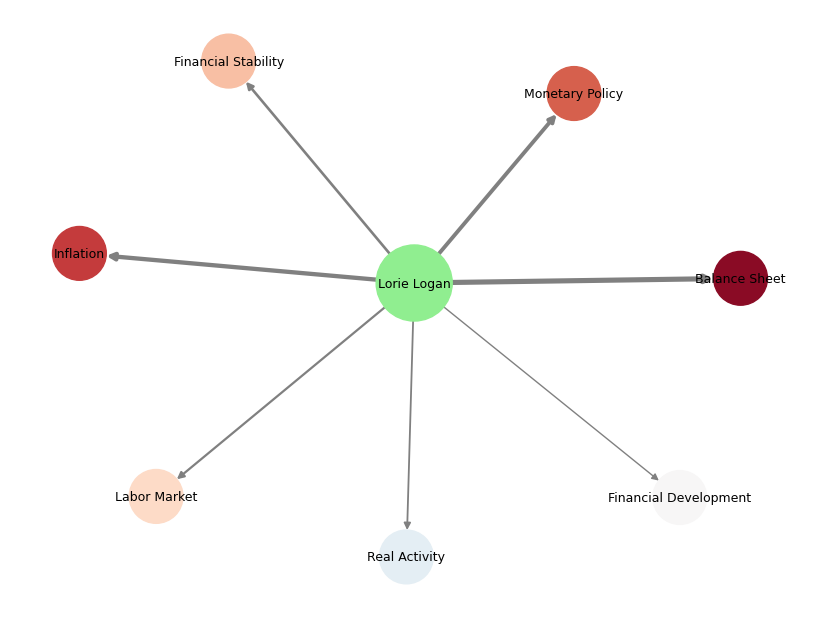

In [37]:
import matplotlib.pyplot as plt
import networkx as nx
from matplotlib import cm
from matplotlib.colors import Normalize
scores = {
    "Balance Sheet": 0.9,
    "Labor Market": 0.2,
    "Inflation": 0.7,
    "Monetary Policy": 0.6,
    "Financial Stability": 0.3,
    "Financial Development": 0.0,
    "Real Activity": -0.1
}
G = nx.DiGraph()
G.add_node("Lorie Logan")

for topic, score in scores.items():
    G.add_node(topic)
    G.add_edge("Lorie Logan", topic, weight=abs(score)*3 + 1)

# Create a colormap from blue (-1) to red (+1)
norm = Normalize(vmin=-1, vmax=1)
cmap = cm.get_cmap("RdBu_r")  # reversed so red = hawkish

# Assign node colors
node_colors = []
for node in G.nodes():
    if node == "Lorie Logan":
        node_colors.append("#90EE90")  # light green for speaker
    else:
        node_colors.append(cmap(norm(scores.get(node, 0))))

# Draw graph
pos = nx.spring_layout(G, seed=42)
plt.figure(figsize=(8, 6))
nx.draw(
    G, pos, with_labels=True,
    node_color=node_colors,
    edge_color="gray",
    width=[G[u][v]['weight'] for u, v in G.edges()],
    node_size=[3000 if n == "Lorie Logan" else 1500 for n in G.nodes()],
    font_size=9,
    arrows=True
)

# Add colorbar legend
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm)
cbar.set_label("Dovish (-1)  ←→  Hawkish (+1)")

plt.title("Lorie Logan: Hawkish/Dovish Stance by Topic", fontsize=12)
plt.tight_layout()
plt.show()
